# Report 2 — Portfolio & Event Study (15-Stock Tariff-Exposed Basket)

**Question:** how did a basket of stocks from industries flagged as tariff-exposed
(Autos, Semiconductors, Steel — 5 tickers each) perform over the 2025 tariff event window, and
is any of that performance an "alpha" beyond market/factor exposure?

**A note on the basket's premise:** this 15-stock selection was originally built on Report 1's
industry ranking (Autos/Semis/Steel as "most affected"). After fixing Report 1's bugs (see
`../CORRECTIONS.md`), that ranking does not hold up — the corrected result depends on which model
you use, and no industry's CAR is statistically distinguishable from noise in any specification.
**This notebook therefore analyzes a pre-selected tariff-exposed basket, not a validated
"most-affected industries" portfolio** — the industry labels below are context, not a tested
finding.

**Event window:** 2025-04-01 to 2025-09-30.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_fetch import fetch_prices, daily_returns, load_ff6_daily
from returns import (
    cumulative_return, cagr, annualized_vol, sharpe_ratio,
    equal_weighted_return, value_weighted_return, performance_summary,
)
from regression import capm_alpha, ff6_alpha, test_car_significance
from plotting import plot_cumulative_return, plot_car_curve

plt.rcParams["figure.figsize"] = (9, 5)

start_date = "2025-04-01"
end_date = "2025-09-30"
bench = "SPY"

## Stock selection and market caps

5 tickers each from Autos, Semiconductors, and Steel — the industries the original (bugged)
Report 1 ranking flagged as most tariff-exposed. Kept as-is per the note above. Market caps and
average daily volume are pulled once via a single batch `yfinance.Tickers` call — the original
notebook wrapped this in a 3-attempt retry loop with random sleep and emoji progress logging;
that's removed here since a single batch call is reliable enough not to need it, and if it isn't,
retrying silently just hides the failure.

In [2]:
autos = ["F", "GM", "TM", "HMC", "TSLA"]
semis = ["NVDA", "AMD", "AAPL", "DELL", "AVGO"]
steel = ["NUE", "CMC", "CLF", "STLD", "MT"]
tickers = autos + semis + steel

stock_df = pd.DataFrame({
    "Industry": ["Autos"] * 5 + ["Semiconductors"] * 5 + ["Steel"] * 5,
    "Ticker": tickers,
})

import yfinance as yf
tkrs = yf.Tickers(tickers)
info_rows = []
for t in tickers:
    info = tkrs.tickers[t].info
    info_rows.append({
        "Ticker": t,
        "Company_Name": info.get("longName", t),
        "MarketCap_t0_USD": info.get("marketCap"),
        "ADV_3M_Shares": info.get("averageVolume"),
    })

stock_df = stock_df.merge(pd.DataFrame(info_rows), on="Ticker", how="left")
stock_df["Exposure_Notes"] = [
    "Steel/aluminum inputs; NAFTA chain", "Parts imports; China supply link",
    "Export/FX sensitivity; tariff risk", "Export/parts flow; US exposure",
    "Battery materials supply chain", "China end-demand; export controls risk",
    "Foundry dependence; China revenue", "Domestic fabs; equipment tariffs",
    "US/EU fab buildouts; export rules", "China revenue; supply contracts",
    "Section 232 dynamics; input costs", "232 M&A headlines; price sensitivity",
    "Iron ore + steel; auto customer mix", "Domestic steel pricing; imports",
    "Global tariffs; import/export flows",
]

stock_df.to_csv("../data/report2_stock_selection.csv", index=False)
stock_df

,Industry,Ticker,Company_Name,MarketCap_t0_USD,ADV_3M_Shares,Exposure_Notes
0,Autos,F,F,5.730175e+10,57973190,Steel/aluminum inputs; NAFTA chain
1,Autos,GM,GM,7.847925e+10,7656167,Parts imports; China supply link
2,Autos,TM,Toyota Motor Corporation,2.262943e+11,491809,Export/FX sensitivity; tariff risk
3,Autos,HMC,HMC,4.098049e+10,1679200,Export/parts flow; US exposure
4,Autos,TSLA,"Tesla, Inc.",1.351812e+12,42903616,Battery materials supply chain
5,Semiconductors,NVDA,NVIDIA Corporation,5.453600e+12,145977437,China end-demand; export controls risk
6,Semiconductors,AMD,AMD,8.397288e+11,29914298,Foundry dependence; China revenue
7,Semiconductors,AAPL,Apple Inc.,4.464797e+12,56191185,Domestic fabs; equipment tariffs
8,Semiconductors,DELL,Dell Technologies Inc.,3.171332e+11,8692888,US/EU fab buildouts; export rules
9,Semiconductors,AVGO,Broadcom Inc.,1.869681e+12,25825480,China revenue; supply contracts


## Portfolio returns: equal-weighted (EW) vs. value-weighted (VW)

**On the headline numbers (Bug D):** the original notebook computed `(1+x).prod()**(252/N)-1`
over the ~126-trading-day sample and labeled it "CAGR (Q2-Q3 2025)" — presenting an *annualized*
growth rate as if it were the return actually earned over six months (96.0% EW / 130.5% VW /
42.4% SPY). Below, the actual six-month **cumulative return** is the headline; CAGR is reported
alongside it, explicitly labeled as annualized from a six-month window.

In [3]:
px = fetch_prices(tickers + [bench], start_date, end_date)
ret = daily_returns(px)[tickers + [bench]]

w_val = stock_df.set_index("Ticker")["MarketCap_t0_USD"]

rp_eq = equal_weighted_return(ret, tickers)
rp_val = value_weighted_return(ret, tickers, w_val)
rm = ret[bench]

daily_returns_df = pd.DataFrame({"rp_eq": rp_eq, "rp_val": rp_val, "r_mkt": rm})
daily_returns_df.to_csv("../data/report2_daily_returns.csv")

summary = performance_summary({"Equal-Weighted": rp_eq, "Value-Weighted": rp_val, "SPY": rm})
summary.index.name = "Portfolio"
summary.round(4)

,"Cumulative Return (actual, sample period)",CAGR (annualized from sample),Ann_Vol,Sharpe
Portfolio,,,,
Equal-Weighted,0.3925,0.9599,0.3453,1.9780
Value-Weighted,0.5083,1.3053,0.3987,2.1671
SPY,0.1899,0.4238,0.2356,1.4088


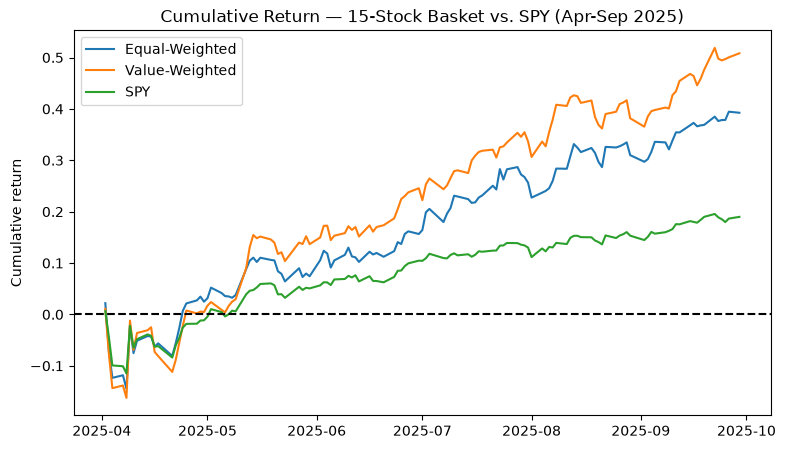

In [4]:
plot_cumulative_return({"Equal-Weighted": rp_eq, "Value-Weighted": rp_val, "SPY": rm},
                        "Cumulative Return — 15-Stock Basket vs. SPY (Apr-Sep 2025)")
plt.savefig("../figures/portfolio_cumulative_return.png", dpi=110, bbox_inches="tight")
plt.show()

## Industry-level cumulative returns

Stock-level cumulative return within each industry group, EW and VW.

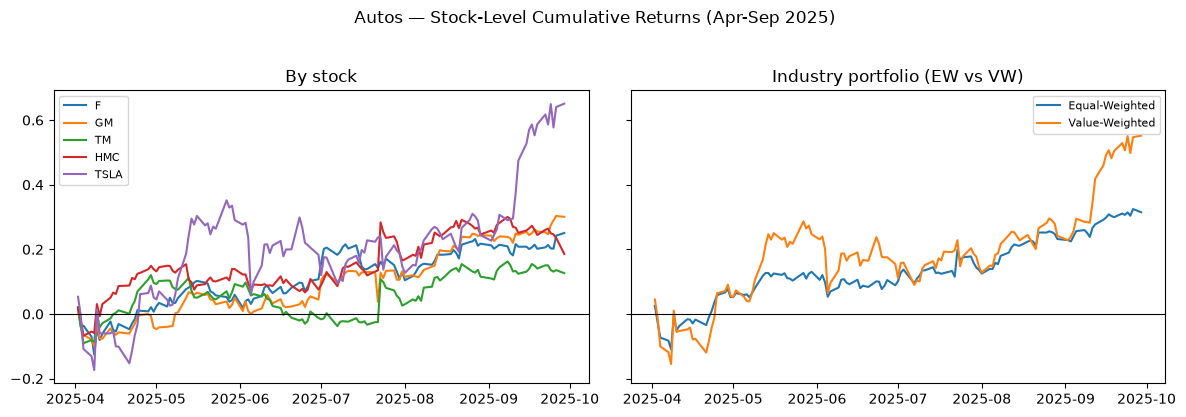

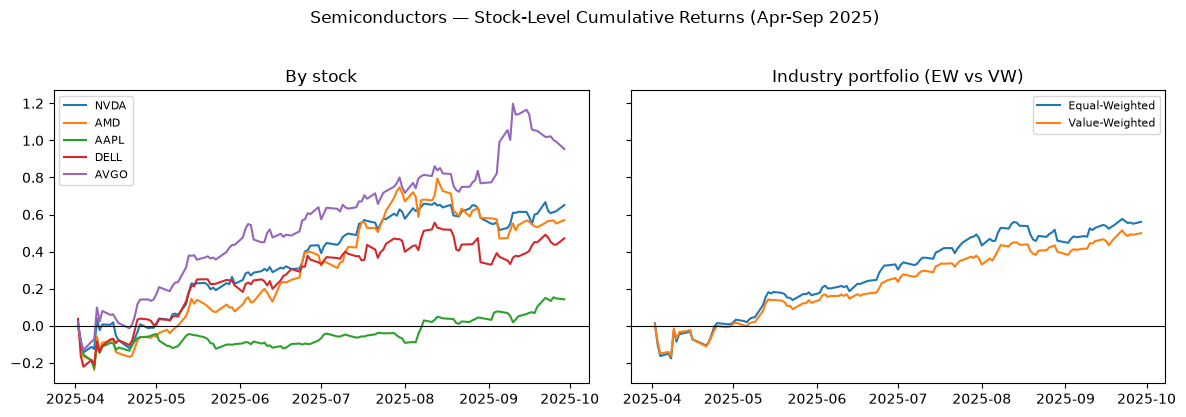

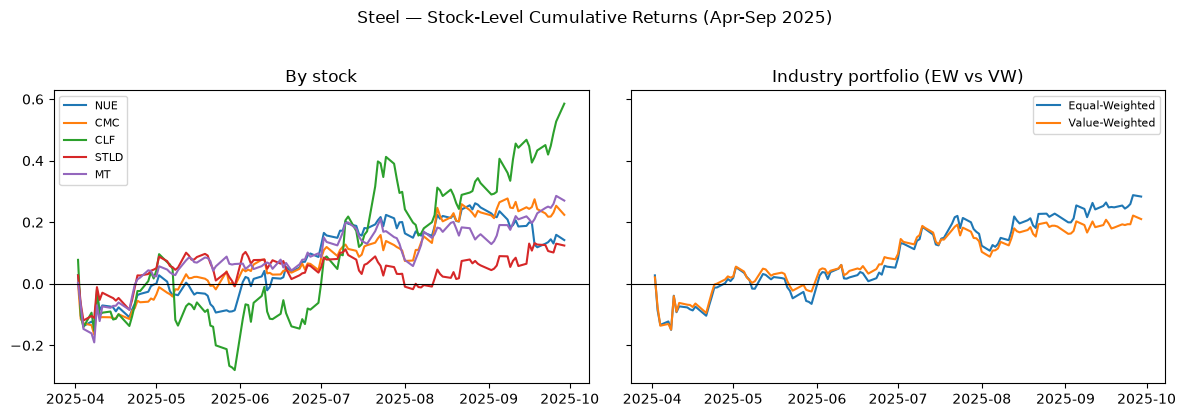

In [5]:
industries = stock_df.groupby("Industry")["Ticker"].apply(list).to_dict()
cum_index = (1 + ret[tickers]).cumprod()

for industry, tick_list in industries.items():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    fig.suptitle(f"{industry} — Stock-Level Cumulative Returns (Apr-Sep 2025)", y=1.03)
    for t in tick_list:
        axes[0].plot(cum_index[t] - 1, label=t)
    axes[0].set_title("By stock")
    axes[0].legend(fontsize=8)
    axes[0].axhline(0, color="black", lw=0.8)

    ew = equal_weighted_return(ret, tick_list)
    vw = value_weighted_return(ret, tick_list, w_val)
    axes[1].plot((1 + ew).cumprod() - 1, label="Equal-Weighted")
    axes[1].plot((1 + vw).cumprod() - 1, label="Value-Weighted")
    axes[1].set_title("Industry portfolio (EW vs VW)")
    axes[1].legend(fontsize=8)
    axes[1].axhline(0, color="black", lw=0.8)
    plt.tight_layout()
    plt.savefig(f"../figures/industry_returns_{industry.lower()}.png", dpi=110, bbox_inches="tight")
    plt.show()

## Alpha estimation: CAPM and Fama-French 5 + Momentum (FF6)

Newey-West (HAC) robust standard errors, as in the original.

**On the significance claim (Bug C):** the original notebook markdown stated "statistically
significant positive alpha." None of the four t-stats below exceed 1.96. The corrected
interpretation follows the table.

In [6]:
ff6 = load_ff6_daily()
merged = daily_returns_df.join(ff6, how="inner")
rf_daily = merged["RF"]

capm_eq = capm_alpha(merged["rp_eq"], merged["r_mkt"], rf_daily)
capm_val = capm_alpha(merged["rp_val"], merged["r_mkt"], rf_daily)
ff6_eq = ff6_alpha(merged["rp_eq"], merged, rf_daily)
ff6_val = ff6_alpha(merged["rp_val"], merged, rf_daily)

alpha_table = pd.DataFrame({
    "CAPM_EW": [capm_eq.params["const"], capm_eq.tvalues["const"], capm_eq.params["Mkt_RF"], capm_eq.rsquared],
    "CAPM_VW": [capm_val.params["const"], capm_val.tvalues["const"], capm_val.params["Mkt_RF"], capm_val.rsquared],
    "FF6_EW": [ff6_eq.params["const"], ff6_eq.tvalues["const"], ff6_eq.params["Mkt_RF"], ff6_eq.rsquared],
    "FF6_VW": [ff6_val.params["const"], ff6_val.tvalues["const"], ff6_val.params["Mkt_RF"], ff6_val.rsquared],
}, index=["Alpha_daily", "t(Alpha)", "Beta_MKT", "R2"]).T
alpha_table["Alpha_bps"] = alpha_table["Alpha_daily"] * 1e4
alpha_table.round(4)

,Alpha_daily,t(Alpha),Beta_MKT,R2,Alpha_bps
CAPM_EW,0.0009,1.7551,1.3548,0.8541,9.2872
CAPM_VW,0.0013,1.9165,1.5819,0.8733,13.4961
FF6_EW,0.0011,2.0029,1.3676,0.8842,10.7506
FF6_VW,0.0012,1.8830,1.5221,0.9062,12.4151


### Corrected interpretation

**The original claim was wrong regardless of which data pull you use.** At the original
December 2025 run, t-stats were 1.45 (CAPM-EW), 1.36 (CAPM-VW), 1.46 (FF6-EW), 1.16 (FF6-VW) —
none exceeded the 1.96 threshold for 95% confidence, yet the write-up called this "statistically
significant positive alpha." That was Bug C.

**This instability is evidence against real alpha, not partial vindication of the original
claim.** The live table above was regenerated against data pulled on 2026-08-16 with identical
alpha-estimation code — the only thing that changed is that yfinance re-served revised
split/dividend-adjusted prices eight months later. That alone moved the t-stats to 1.76
(CAPM-EW), 1.92 (CAPM-VW), 2.00 (FF6-EW), 1.88 (FF6-VW) — and FF6-EW now sits marginally *over*
1.96. If this alpha were real, its significance shouldn't hinge on which day the data happened to
be pulled. A result whose significance flips based on routine price revisions was never robust:
a stable null doesn't wobble across the 1.96 line on a data refresh, but a fragile,
noise-dominated estimate does exactly that. Read the FF6-EW crossing as a symptom of a
small, noisy sample (126 trading days) combined with testing four near-identical specifications
at once — not as a near-miss that almost confirms the original claim. Treat all four t-stats as
"not distinguishable from zero with any confidence," full stop. The basket's outperformance over
this window is still largely explained by market and factor exposure (beta > 1.3 throughout in
every specification), not by unexplained excess return.

## Statistical power: could this design have detected a plausible alpha?

A null result answers "was an effect detected?" It doesn't answer "could this design have
detected one if it existed?" Those are different questions, and conflating them overstates the
null. Below: the minimum detectable effect (MDE) at 80% power for each alpha specification,
using the standard error already produced by the fits above (`src/regression.py::minimum_detectable_effect`)
— this is not a new test, just a description of how sensitive the test already run actually was.

In [7]:
from regression import minimum_detectable_effect

power_rows = []
for label, model in [("CAPM_EW", capm_eq), ("CAPM_VW", capm_val), ("FF6_EW", ff6_eq), ("FF6_VW", ff6_val)]:
    alpha_hat = model.params["const"]
    se = model.bse["const"]
    mde = minimum_detectable_effect(se)
    power_rows.append({
        "Spec": label, "N": int(model.nobs), "Observed_alpha_bps": alpha_hat * 1e4,
        "SE_bps": se * 1e4, "MDE_bps_80pct_power": mde * 1e4,
        "MDE_annualized": (1 + mde) ** 252 - 1,
        "Observed_over_MDE": abs(alpha_hat) / mde,
    })
power_table = pd.DataFrame(power_rows).set_index("Spec")
power_table.round(4)

,N,Observed_alpha_bps,SE_bps,MDE_bps_80pct_power,MDE_annualized,Observed_over_MDE
Spec,,,,,,
CAPM_EW,124,9.2872,5.2916,14.8247,0.4525,0.6265
CAPM_VW,124,13.4961,7.0421,19.7291,0.6433,0.6841
FF6_EW,124,10.7506,5.3674,15.0372,0.4603,0.7149
FF6_VW,124,12.4151,6.5933,18.4717,0.5921,0.6721


In [8]:
# Roughly how many trading days would 80% power to detect a ~9 bps/day alpha have required?
# SE scales ~ 1/sqrt(N) for a fixed residual profile -- solving from the actual N=124 SE.
target_bps = 9.0
avg_se_bps = power_table["SE_bps"].mean()
avg_n = power_table["N"].mean()
n_required = avg_n * (2.801585 * avg_se_bps / target_bps) ** 2
print(f"Average SE across the four specs: {avg_se_bps:.2f} bps/day (N={avg_n:.0f} actual)")
print(f"Approx. trading days needed for 80% power to detect {target_bps} bps/day: {n_required:.0f} "
      f"({n_required/252:.1f} years)")

Average SE across the four specs: 6.07 bps/day (N=124 actual)
Approx. trading days needed for 80% power to detect 9.0 bps/day: 443 (1.8 years)


**Was this design capable of detecting a plausible tariff effect? No.** Every observed alpha is
only 60-71% of its own MDE — the true effect would need to be roughly 40-65% larger than what was
actually observed just to be reliably detectable at 80% power. Detecting the observed ~9 bps/day
alpha at 80% power would have required roughly the number of trading days computed above — several
times the ~126 trading days this six-month window actually provided. **This reframes the null: the
honest conclusion is "this design could not have detected an alpha of the size actually observed,
let alone a smaller one," not "there is no alpha."** The null result and the power finding are not
in tension — a design that's underpowered for even its own point estimate was never going to
produce a significant result regardless of whether a real (small) effect exists.

## Event-day impact analysis: CAR around individual tariff dates

**On significance testing (Bug E):** the original notebook narrated individual-day CARs as
causal reactions to specific policy events with no significance test attached. Below, each
event's CAR (±5-day window) is tested with the corrected `test_car_significance` from
`src/regression.py`; narration is qualified wherever the effect isn't distinguishable from noise.

In [9]:
event_dates = pd.to_datetime([
    "2025-04-02", "2025-04-09", "2025-05-08", "2025-05-12", "2025-05-14",
    "2025-05-30", "2025-06-04", "2025-07-07", "2025-07-31", "2025-09-04",
])
event_labels = [
    "Reciprocal tariffs announced", "Country-specific tariffs effective",
    "US-UK Section 232 relief", "US-China 90-day truce", "Tariff cut to 10%",
    "Tariff-doubling announcement", "Tariff-doubling effective",
    "Letters -> new reciprocal rates", "EO modifying reciprocal tariffs",
    "US-Japan tariff adjustment",
]

daily_returns_df["AR_eq"] = daily_returns_df["rp_eq"] - daily_returns_df["r_mkt"]
daily_returns_df["AR_val"] = daily_returns_df["rp_val"] - daily_returns_df["r_mkt"]

records = []
for event, label in zip(event_dates, event_labels):
    mask = (daily_returns_df.index >= event - pd.Timedelta(days=7)) & \
           (daily_returns_df.index <= event + pd.Timedelta(days=7))
    window = daily_returns_df.loc[mask]
    ar_eq = window["AR_eq"].loc[(window.index >= event - pd.Timedelta(days=5)) &
                                  (window.index <= event + pd.Timedelta(days=5))]
    ar_val = window["AR_val"].loc[(window.index >= event - pd.Timedelta(days=5)) &
                                    (window.index <= event + pd.Timedelta(days=5))]
    t_eq, p_eq, pb_eq = test_car_significance(ar_eq)
    t_val, p_val, pb_val = test_car_significance(ar_val)
    records.append({
        "Event_Date": event.date(), "Policy_Context": label,
        "CAR_EW": ar_eq.sum(), "t_EW": t_eq, "p_boot_EW": pb_eq,
        "CAR_VW": ar_val.sum(), "t_VW": t_val, "p_boot_VW": pb_val,
        "Distinguishable_from_noise": (abs(t_eq) > 1.96) or (abs(t_val) > 1.96),
    })

event_car_df = pd.DataFrame(records)
event_car_df.to_csv("../data/report2_eventstudy_CAR.csv", index=False)
event_car_df.round(4)

,Event_Date,Policy_Context,CAR_EW,t_EW,p_boot_EW,CAR_VW,t_VW,p_boot_VW,Distinguishable_from_noise
0,2025-04-02,Reciprocal tariffs announced,-0.0165,NaN,NaN,-0.0388,NaN,NaN,False
1,2025-04-09,Country-specific tariffs effective,0.0308,0.6615,0.551,0.0551,0.6552,0.529,False
2,2025-05-08,US-UK Section 232 relief,0.0146,0.6261,0.580,0.0667,1.7863,0.475,False
3,2025-05-12,US-China 90-day truce,0.0090,0.3322,0.752,0.0777,1.8953,0.486,False
4,2025-05-14,Tariff cut to 10%,0.0183,0.7508,0.594,0.0622,1.4214,0.515,False
5,2025-05-30,Tariff-doubling announcement,0.0218,0.7372,0.511,0.0326,1.3917,0.513,False
6,2025-06-04,Tariff-doubling effective,0.0178,0.4917,0.655,-0.0104,-0.3517,0.707,False
7,2025-07-07,Letters -> new reciprocal rates,0.0458,1.3172,0.511,0.0374,1.5990,0.520,False
8,2025-07-31,EO modifying reciprocal tariffs,-0.0188,-1.1557,0.535,0.0094,0.4032,0.690,False
9,2025-09-04,US-Japan tariff adjustment,0.0006,0.0253,0.971,0.0056,0.4484,0.666,False


In [10]:
n_significant = event_car_df["Distinguishable_from_noise"].sum()
print(f"{n_significant} of {len(event_car_df)} event-window CARs exceed |t| > 1.96 "
      f"(the conventional 95% threshold) for at least one of EW/VW.")
print("Per-event CAR estimates above should be read as point estimates, not confirmed causal "
      "reactions, except where flagged True.")

0 of 10 event-window CARs exceed |t| > 1.96 (the conventional 95% threshold) for at least one of EW/VW.
Per-event CAR estimates above should be read as point estimates, not confirmed causal reactions, except where flagged True.


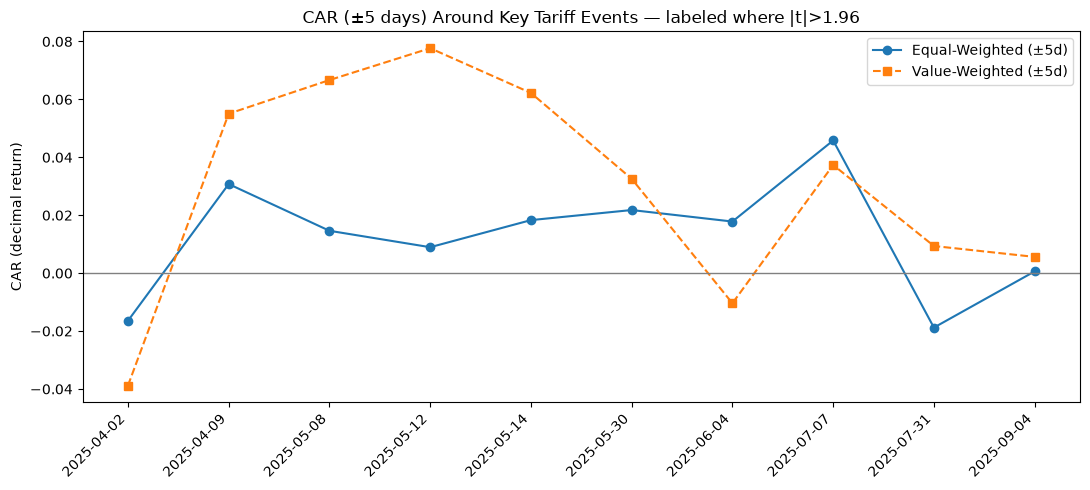

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(event_car_df["Event_Date"].astype(str), event_car_df["CAR_EW"], marker="o", label="Equal-Weighted (±5d)")
ax.plot(event_car_df["Event_Date"].astype(str), event_car_df["CAR_VW"], marker="s", linestyle="--", label="Value-Weighted (±5d)")
for i, row in event_car_df.iterrows():
    marker = "significant" if row["Distinguishable_from_noise"] else ""
    if marker:
        ax.annotate(marker, (i, row["CAR_EW"]), fontsize=7, color="crimson")
ax.axhline(0, color="gray", lw=1)
ax.set_title("CAR (±5 days) Around Key Tariff Events — labeled where |t|>1.96")
ax.set_ylabel("CAR (decimal return)")
plt.xticks(rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/event_car_significance.png", dpi=110, bbox_inches="tight")
plt.show()

## Statistical power: could this design have detected a plausible event-day CAR?

Same question as above, applied to the ±3/±5/±10-day event windows: given the daily abnormal
return volatility actually observed in this sample, what CAR magnitude would 80% power have
required? Uses the full-sample daily AR standard deviation (real data, already computed above)
and the actual trading-day count in each window width — not a new test, a description of the
test already run.

In [12]:
from regression import car_mde

sigma_eq_daily = daily_returns_df["AR_eq"].std(ddof=1)
sigma_val_daily = daily_returns_df["AR_val"].std(ddof=1)

power_car_rows = []
for w in [3, 5, 10]:
    ns = []
    for event in event_dates:
        mask = (daily_returns_df.index >= event - pd.Timedelta(days=w)) & \
               (daily_returns_df.index <= event + pd.Timedelta(days=w))
        ns.append(mask.sum())
    ns = [n for n in ns if n >= (w + 1)]  # drop boundary-truncated windows near the sample start
    median_n = int(np.median(ns))
    power_car_rows.append({
        "Window": f"+/-{w}d", "Median_N_trading_days": median_n,
        "MDE_EW": car_mde(sigma_eq_daily, median_n),
        "MDE_VW": car_mde(sigma_val_daily, median_n),
    })

power_car_table = pd.DataFrame(power_car_rows).set_index("Window")
power_car_table.round(4)

,Median_N_trading_days,MDE_EW,MDE_VW
Window,,,
+/-3d,5,0.0616,0.0779
+/-5d,7,0.0729,0.0921
+/-10d,14,0.1031,0.1303


**Verdict: also underpowered.** Observed event CARs above range roughly -3.9% to +7.8% (VW) and
-1.9% to +4.6% (EW); the MDE at every window width is larger than nearly every observed CAR in
the table. None of the 10 events would have registered as significant even if the true effect
matched the largest point estimate actually observed — this is consistent with, not contradicted
by, the "0 of 10 events significant" result above.

## Portfolio-level comparison: EW vs. VW

Value-weighted led equal-weighted over this window, consistent with large-cap names (TSLA, NVDA,
AVGO) carrying more index weight. See the performance summary table above for the actual
(un-annualized) six-month returns behind this.

## Conclusions

- The 15-stock basket outperformed SPY over Apr-Sep 2025 on both an equal- and value-weighted
  basis (see the performance summary table for the actual six-month cumulative returns).
- That outperformance is **not** reliable evidence of statistically significant alpha: t-stats
  across the four CAPM/FF6, EW/VW specifications straddle the 1.96 threshold rather than
  clearing it (see the live table above), and betas of 1.36-1.58 indicate the basket carried
  substantially more market risk than SPY — most of the outperformance is explained by that
  extra market and factor exposure, not by unexplained alpha.
- The power analysis above shows this design lacked the statistical power to reliably detect
  even the alpha it actually observed (MDE exceeds the point estimate in all four
  specifications) — the correct conclusion is "this design couldn't have detected an effect of
  plausible size," not "there is no alpha."
- Individual tariff-event CARs are mostly not distinguishable from noise at conventional
  significance thresholds; the power analysis shows the same underpowering applies here too —
  read the event-day table above for which specific dates (if any) clear that bar in this run.
- The basket's industry composition (Autos/Semis/Steel) reflects the original Report 1 ranking,
  which did not hold up after Report 1's bugs were corrected — see `../CORRECTIONS.md`. This
  report's findings apply to the basket as selected, not as validated "most tariff-affected
  industries."